In [1]:
import msprime
from demography import DemographicTopology
import numpy as np

In [2]:
## Defining Topology
dem = DemographicTopology(['a', 'admix', 'b', 'c'])

dem.add_admixture_event('admix', 'admixPa1', 'admixPa2') # Admixture event: from Admix to Admixpa1 and Admixpa2
dem.add_merge_event('a', 'admixPa1', 'aAdmix')  # Merge event: from A and Admixpa1 to Aadmix
dem.add_merge_event('b', 'admixPa2', 'bAdmix')
dem.add_merge_event('aAdmix', 'bAdmix', 'subAnc')
dem.add_merge_event('subAnc', 'c', 'anc')


[Event 0] Admixture: admix -> admixPa1 & admixPa2
[Event 2] Merge: a & admixPa1 -> aAdmix
[Event 3] Merge: b & admixPa2 -> bAdmix
[Event 4] Merge: aAdmix & bAdmix -> subAnc
[Event 5] Merge: subAnc & c -> anc


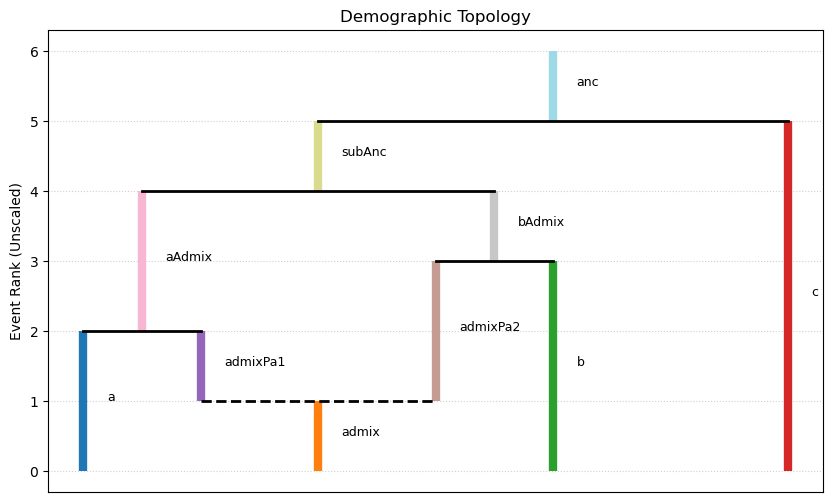

In [3]:
# Under scale = False, you can plot the graph without knowing the parameters. 
dem.plot_demography(scale = False)

In [16]:
# Effective Population Sizes
dem.set_node_ne('a', 3000)
dem.set_node_ne('b', 3000)
dem.set_node_ne('c', 3000)
dem.set_node_ne('admix', 3000)
dem.set_node_ne('admixPa1', 3000)
dem.set_node_ne('admixPa2', 3000)
dem.set_node_ne('aAdmix', 3000)
dem.set_node_ne('bAdmix', 3000)
dem.set_node_ne('subAnc', 3000)
dem.set_node_ne('anc', 3000)

dem.set_admixture_parameters('admix',50, 0.75, 'admixPa1')
dem.set_merge_time('aAdmix', 51)
dem.set_merge_time('bAdmix', 52)
dem.set_merge_time('subAnc',500)
dem.set_merge_time('anc', 1000)
dem.finalize_root()

[Finalize] Set anc time_end to infinity.


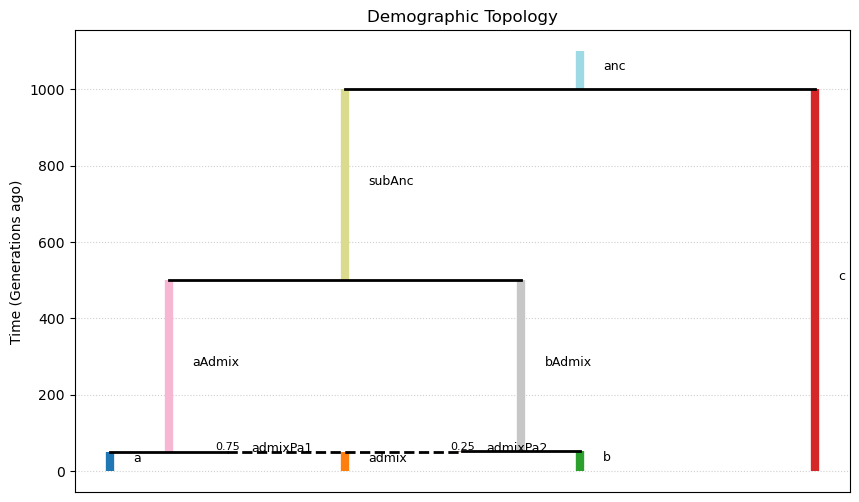

In [17]:
# This plot is sclaed by true time
dem.plot_demography(scale = True)

In [7]:
# For simulation block, first translate to msprime format
from simulation_methods import to_msprime_demography

msp = to_msprime_demography(dem)
msp.debug()

In [18]:
# This block output the pruned snp frequencies table
from simulation_methods import simulate_msprime, simulate_snp_pruning, calculate_ibd_fractions_mrca

# recombination rate set to default 1e-8, thus sequence_length * recombination_rate gives the number of morgans.
mts = simulate_msprime(dem, 
                       sequence_length = 5e6, 
                       recombination_rate = 1e-7, 
                       mutation_rate = 1e-7,
                       samples_per_pop = {'a': 30, 'b': 20, 'c': 10, 'admix': 40})

ids, freq_array = simulate_snp_pruning(
    mts,
    dem,
    temporal_folder = './plink_output',
    cutoff_time = 1000
)


Running: plink --vcf plink_output/snp_ts.vcf --make-bed --out plink_output/snp_ts --double-id --allow-extra-chr --silent
Running: plink --bfile plink_output/snp_ts --indep-pairwise 100 5 0.2 --out plink_output/pruned --allow-extra-chr --silent
LD pruning complete. Kept 2058 SNPs.


In [19]:
bins = [[0.5,0.6],[0.6,0.7],[0.7,0.8],[0.8,0.9],[0.9,1.0],[1.0,1.5],[1.5,2],[2,5],[5,300]]
ibd_mean, ibd_sd = calculate_ibd_fractions_mrca(mts,bins = bins, cm_per_unit=1e-5, num_bootstraps = 1000)

Scanning trees for MRCA segments (19900 pairs)...


In [20]:
from simulation_methods import build_ibd_stan_data
effective_N = np.array([6000]*10)
stan_ibd = build_ibd_stan_data(dem, ibd_mean, ibd_sd, bins, effective_N = effective_N)

[build_ibd_stan_data] T_max not provided — using 100 * max(N) = 600000 generations
[build_ibd_stan_data] Stan data assembled (corrected joint-path model):
  n_leaves     : 4
  n_nodes      : 10
  n_events     : 5
  n_admixture  : 1
  n_leaf_pairs : 10
  n_bins       : 9
  T_max        : 600000 generations
  ibd_hat      : [0.000e+00, 6.318e-03]
  ibd_se       : [1.000e-08,  1.947e-03]


In [21]:
from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file="ibd_model_Nfixed.stan")

fit   = model.sample(data=stan_ibd, chains=4, iter_sampling=4000)

11:37:09 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/5000 [00:00<?, ?it/s, (Warmup)]




chain 1:   2%|▏         | 100/5000 [00:01<01:15, 64.58it/s, (Warmup)]


chain 1:   4%|▍         | 200/5000 [00:02<00:52, 91.66it/s, (Warmup)]


chain 1:   6%|▌         | 300/5000 [00:02<00:41, 113.73it/s, (Warmup)]

chain 1:   8%|▊         | 400/5000 [00:03<00:33, 136.70it/s, (Warmup)]





chain 1:  10%|█         | 500/5000 [00:04<00:38, 118.07it/s, (Warmup)]


chain 1:  12%|█▏        | 600/5000 [00:05<00:32, 135.31it/s, (Warmup)]


chain 1:  14%|█▍        | 700/5000 [00:05<00:28, 148.61it/s, (Warmup)]


chain 1:  16%|█▌        | 800/5000 [00:06<00:26, 160.77it/s, (Warmup)]




chain 1:  18%|█▊        | 900/5000 [00:06<00:23, 174.94it/s, (Warmup)]


chain 1:  20%|██        | 1000/5000 [00:07<00:21, 187.20it/s, (Sampling)]



chain 1:  22%|██▏       | 1100/5000 [00:07<00:20, 186.57it/s, (Sampling)]


chain 1:  26%|██▌       | 1300/5000 [00:08<00:18, 198.83it/s, (Sampli


11:37:43 - cmdstanpy - INFO - CmdStan done processing.


11:37:43 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 12 divergent transitions (0.3%)
	Chain 2 had 1 divergent transitions (0.0%)
	Chain 3 had 9 divergent transitions (0.2%)
	Chain 4 had 3 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [25]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-57.437600,0.033370,1.977180e+00,1.78022,-61.080200,-57.127600,-54.768600,3736.08,4353.03,40.7091,1.00030
times[1],42.372400,0.076314,4.295110e+00,3.77834,34.139800,42.989500,48.257100,4003.97,2428.87,43.6281,1.00082
times[2],5.479220,0.074027,3.967210e+00,3.31655,1.274990,4.362540,13.629400,3451.55,2504.60,37.6088,1.00141
times[3],13.061700,0.078706,5.756270e+00,5.87306,3.796540,12.853300,22.955400,4651.29,2907.04,50.6814,1.00048
times[4],408.145000,0.111372,9.230460e+00,9.19689,393.038000,408.026000,423.341000,6910.43,8072.63,75.2975,1.00043
...,...,...,...,...,...,...,...,...,...,...,...
"ibd_fraction[9,3,4]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"ibd_fraction[9,4,1]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"ibd_fraction[9,4,2]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"ibd_fraction[9,4,3]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
np.mean(fit.admixture_fractions)

np.float64(0.761330054134375)

In [72]:
from inference_methods import calculate_treemix_covariance

w_hat, w_se = calculate_treemix_covariance(
    freq_array,
    min_maf = 0.05,
    block_size_snps = 400
)